# Grokking Transformer — Training Notebook

Self-contained training script for the one-layer transformer from  
**"Progress Measures for Grokking via Mechanistic Interpretability"** (Nanda et al.).

Saves intermediate checkpoints every `save_every` epochs in the `full_run_data.pth`  
format expected by `Grokking_Analysis.ipynb`.  
Works on both a **local machine** (CPU or CUDA) and **Google Colab**.

## Environment Setup

In [1]:
import os, sys
from pathlib import Path

# ── Detect Colab ──
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in: {'Google Colab' if IN_COLAB else 'Local environment'}")

if IN_COLAB:
    # Install dependencies not available by default on Colab
    get_ipython().system('pip install -q einops wandb')

    # Mount Google Drive for persistent storage
    from google.colab import drive
    drive.mount('/content/drive')

    SAVE_ROOT = Path('/content/drive/MyDrive/Grokking')
    SAVE_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Checkpoints will be saved to Google Drive: {SAVE_ROOT}")
else:
    SAVE_ROOT = Path(os.getcwd()) / 'large_files'
    SAVE_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Checkpoints will be saved to: {SAVE_ROOT}")

Running in: Google Colab
Mounted at /content/drive
Checkpoints will be saved to Google Drive: /content/drive/MyDrive/Grokking


In [2]:
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import random
import time
import wandb
from dataclasses import dataclass
from collections import defaultdict

## Configuration

In [3]:
@dataclass(frozen=True)
class CONFIG:
    # ── Optimisation ──
    lr: float = 1e-3
    weight_decay: float = 1.0
    num_epochs: int = 40_000              # synchronised with analysis notebook

    # ── Task ──
    p: int = 67 #distinct, originally 113                          # prime modulus
    fn_name: str = 'add'                  # 'add' or 'subtract'
    frac_train: float = 0.3
    seed: int = 0

    # ── Architecture ──
    num_layers: int = 1
    d_model: int = 128
    num_heads: int = 4
    n_ctx: int = 3
    act_type: str = 'ReLU'               # 'ReLU' or 'GeLU'
    use_ln: bool = False

    # ── Derived ──
    @property
    def d_vocab(self):  return self.p + 1
    @property
    def d_mlp(self):    return 4 * self.d_model
    @property
    def d_head(self):   return self.d_model // self.num_heads

    # ── Checkpointing ──
    save_every: int = 100                 # save state_dict every N epochs
    stopping_thresh: float = -1.0

    # ── W&B logging ──
    log_every: int = 100

    # ── Device ──
    @property
    def device(self):
        return t.device('cuda' if t.cuda.is_available() else 'cpu')

    # ── Supported operations ──
    @property
    def fn(self):
        fns = {
            'add':      lambda x, y: (x + y) % self.p,
            'subtract': lambda x, y: (x - y) % self.p,
        }
        return fns[self.fn_name]

config = CONFIG()
print(f"Device     : {config.device}")
print(f"Task       : {config.fn_name}  mod {config.p}")
print(f"Epochs     : {config.num_epochs:,}")
print(f"Save every : {config.save_every}")
print(f"Checkpoints: {config.num_epochs // config.save_every + 1}")

Device     : cuda
Task       : add  mod 67
Epochs     : 40,000
Save every : 100
Checkpoints: 401


## Helper utilities

In [4]:
def cross_entropy_high_precision(logits, labels):
    """CE loss in float64 to avoid float32 log-softmax underflow."""
    logprobs = F.log_softmax(logits.to(t.float64), dim=-1)
    prediction_logprobs = t.gather(logprobs, index=labels[:, None], dim=-1)
    return -t.mean(prediction_logprobs)


def gen_train_test(config):
    """Generate a deterministic train/test split of all (i, j, p) triples."""
    pairs = [(i, j, config.p) for i in range(config.p) for j in range(config.p)]
    random.seed(config.seed)
    random.shuffle(pairs)
    div = int(config.frac_train * len(pairs))
    return pairs[:div], pairs[div:]

## Model definition

In [5]:
class HookPoint(nn.Module):
    """Identity module that exposes forward/backward hooks for caching activations.
    Inert during training; used by the analysis notebook to inspect internals."""
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []

    def give_name(self, name):
        self.name = name

    def add_hook(self, hook, dir='fwd'):
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir == 'fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        elif dir == 'bwd':
            handle = self.register_backward_hook(full_hook)
            self.bwd_hooks.append(handle)
        else:
            raise ValueError(f"Invalid direction {dir}")

    def remove_hooks(self, dir='fwd'):
        if dir in ('fwd', 'both'):
            for h in self.fwd_hooks: h.remove()
            self.fwd_hooks = []
        if dir in ('bwd', 'both'):
            for h in self.bwd_hooks: h.remove()
            self.bwd_hooks = []

    def forward(self, x):
        return x

In [6]:
class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_model))

    def forward(self, x):
        return t.einsum('dbp -> bpd', self.W_E[:, x])


class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_vocab))

    def forward(self, x):
        return x @ self.W_U


class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(t.randn(max_ctx, d_model) / np.sqrt(d_model))

    def forward(self, x):
        return x + self.W_pos[:x.shape[-2]]

In [7]:
class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx, model):
        super().__init__()
        self.model = model
        self.W_K = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_Q = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_V = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_O = nn.Parameter(t.randn(d_model, d_head * num_heads) / np.sqrt(d_model))
        self.register_buffer('mask', t.tril(t.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()

    def forward(self, x):
        k = self.hook_k(t.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(t.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(t.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = t.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked = t.tril(attn_scores_pre) - 1e10 * (1 - self.mask[:x.shape[-2], :x.shape[-2]])
        attn_matrix = self.hook_attn(
            F.softmax(self.hook_attn_pre(attn_scores_masked / np.sqrt(self.d_head)), dim=-1)
        )
        z = self.hook_z(t.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        return t.einsum('df,bqf->bqd', self.W_O, z_flat)

In [8]:
class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type, model):
        super().__init__()
        self.model = model
        self.W_in = nn.Parameter(t.randn(d_mlp, d_model) / np.sqrt(d_model))
        self.b_in = nn.Parameter(t.zeros(d_mlp))
        self.W_out = nn.Parameter(t.randn(d_model, d_mlp) / np.sqrt(d_model))
        self.b_out = nn.Parameter(t.zeros(d_model))
        self.act_type = act_type
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
        assert act_type in ('ReLU', 'GeLU')

    def forward(self, x):
        x = self.hook_pre(t.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type == 'ReLU':
            x = F.relu(x)
        elif self.act_type == 'GeLU':
            x = F.gelu(x)
        x = self.hook_post(x)
        return t.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, model):
        super().__init__()
        self.model = model
        self.attn = Attention(d_model, num_heads, d_head, n_ctx, model=model)
        self.mlp = MLP(d_model, d_mlp, act_type, model=model)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()

    def forward(self, x):
        x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.hook_resid_pre(x))))
        x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(x)))
        return x


class Transformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_mlp, d_head,
                 num_heads, n_ctx, act_type, use_cache=False, use_ln=False):
        super().__init__()
        self.cache = {}
        self.use_cache = use_cache
        self.use_ln = use_ln
        self.embed = Embed(d_vocab=d_vocab, d_model=d_model)
        self.pos_embed = PosEmbed(max_ctx=n_ctx, d_model=d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model=d_model, d_mlp=d_mlp, d_head=d_head,
                num_heads=num_heads, n_ctx=n_ctx,
                act_type=act_type, model=[self],
            )
            for _ in range(num_layers)
        ])
        self.unembed = Unembed(d_vocab=d_vocab, d_model=d_model)
        for name, module in self.named_modules():
            if isinstance(module, HookPoint):
                module.give_name(name)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        return self.unembed(x)

    def hook_points(self):
        return [m for n, m in self.named_modules() if 'hook' in n]

    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')

    def cache_all(self, cache, incl_bwd=False):
        def save_hook(tensor, name):
            cache[name] = tensor.detach()
        def save_hook_back(tensor, name):
            cache[name + '_grad'] = tensor[0].detach()
        for hp in self.hook_points():
            hp.add_hook(save_hook, 'fwd')
            if incl_bwd:
                hp.add_hook(save_hook_back, 'bwd')

## Training

The training loop collects `state_dicts` every `save_every` epochs and packages  
everything into `full_run_data.pth` — the format expected by `Grokking_Analysis.ipynb`:

| Key | Shape | Description |
|---|---|---|
| `state_dicts` | list of 401 | Model weights at epochs 0, 100, …, 40000 |
| `epochs` | list of 401 | Corresponding epoch numbers |
| `train_losses` | list of 40000 | Per-epoch training loss |
| `test_losses` | list of 40000 | Per-epoch test loss |
| `config` | dict | Hyperparameters |

In [10]:
class Trainer:
    def __init__(self, config, save_root):
        import dataclasses
        wandb.init(project="grokking", config=dataclasses.asdict(config))
        self.config = config
        self.save_root = save_root

        # Build model (constructor signature matches analysis notebook)
        self.model = Transformer(
            num_layers=config.num_layers, d_vocab=config.d_vocab,
            d_model=config.d_model, d_mlp=config.d_mlp, d_head=config.d_head,
            num_heads=config.num_heads, n_ctx=config.n_ctx,
            act_type=config.act_type, use_cache=False, use_ln=config.use_ln,
        )
        self.model.to(config.device)

        self.optimizer = optim.AdamW(
            self.model.parameters(), lr=config.lr,
            weight_decay=config.weight_decay, betas=(0.9, 0.98),
        )
        self.scheduler = optim.lr_scheduler.LambdaLR(
            self.optimizer, lambda step: min(step / 10, 1)
        )

        self.train_data, self.test_data = gen_train_test(config)
        self.train_losses = []
        self.test_losses = []

        # ── Checkpoint accumulator ──
        self.saved_state_dicts = []
        self.saved_epochs = []

        print(f"Training samples : {len(self.train_data)}")
        print(f"Test samples     : {len(self.test_data)}")

    def full_loss(self, data):
        logits = self.model(data)[:, -1]
        labels = t.tensor([self.config.fn(i, j) for i, j, _ in data]).to(self.config.device)
        return cross_entropy_high_precision(logits, labels)

    def save_checkpoint(self, epoch):
        """Snapshot current model weights (moved to CPU to save GPU memory)."""
        sd = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
        self.saved_state_dicts.append(sd)
        self.saved_epochs.append(epoch)

    def step(self, epoch):
        train_loss = self.full_loss(self.train_data)
        test_loss = self.full_loss(self.test_data)
        self.train_losses.append(train_loss.item())
        self.test_losses.append(test_loss.item())

        if epoch % self.config.log_every == 0:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss.item(),
                "test_loss": test_loss.item(),
            })
            print(
                f"Epoch {epoch:>6d} | "
                f"train {t.log(train_loss).item():+.4f} | "
                f"test {t.log(test_loss).item():+.4f}"
            )

        train_loss.backward()
        self.optimizer.step()
        self.scheduler.step()
        self.optimizer.zero_grad()
        return train_loss, test_loss

    def save_full_run_data(self):
        """Write the full_run_data.pth file in the format Grokking_Analysis expects."""
        import dataclasses
        save_path = self.save_root / 'full_run_data.pth'
        full_run_data = {
            'state_dicts':  self.saved_state_dicts,
            'epochs':       self.saved_epochs,
            'train_losses': self.train_losses,
            'test_losses':  self.test_losses,
            'config':       dataclasses.asdict(self.config),
        }
        t.save(full_run_data, save_path)
        wandb.save(str(save_path))
        n = len(self.saved_state_dicts)
        size_mb = save_path.stat().st_size / 1e6
        print(f"\nSaved {n} checkpoints → {save_path}  ({size_mb:.1f} MB)")

In [11]:
trainer = Trainer(config, save_root=SAVE_ROOT)

for epoch in range(config.num_epochs):
    # Save checkpoint BEFORE the training step (epoch 0 = initial weights)
    if epoch % config.save_every == 0:
        trainer.save_checkpoint(epoch)

    train_loss, test_loss = trainer.step(epoch)

    if config.stopping_thresh > 0 and test_loss.item() < config.stopping_thresh:
        print(f"\nTest loss below threshold ({config.stopping_thresh}) at epoch {epoch}.")
        break

# Save the final state (after all training) as the last checkpoint
trainer.save_checkpoint(config.num_epochs)
print(f"\nTotal checkpoints: {len(trainer.saved_state_dicts)}")
print(f"  Index 0   = epoch {trainer.saved_epochs[0]}  (initial weights)")
print(f"  Index {len(trainer.saved_state_dicts)-1} = epoch {trainer.saved_epochs[-1]}  (final weights)")

trainer.save_full_run_data()
wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Training samples : 1346
Test samples     : 3143
Epoch      0 | train +1.4508 | test +1.4524
Epoch    100 | train -1.1998 | test +2.3754
Epoch    200 | train -4.7811 | test +2.6595
Epoch    300 | train -5.9341 | test +2.6893
Epoch    400 | train -7.0656 | test +2.7306
Epoch    500 | train -8.1754 | test +2.7786
Epoch    600 | train -9.2712 | test +2.8288
Epoch    700 | train -10.3511 | test +2.8801
Epoch    800 | train -11.4094 | test +2.9297
Epoch    900 | train -12.4322 | test +2.9763
Epoch   1000 | train -13.3849 | test +3.0177
Epoch   1100 | train -14.2115 | test +3.0532
Epoch   1200 | train -14.8495 | test +3.0803
Epoch   1300 | train -15.2594 | test +3.0961
Epoch   1400 | train -15.4580 | test +3.1021
Epoch   1500 | train -15.5208 | test +3.1014
Epoch   1600 | train -15.5333 | test +3.0978
Epoch   1700 | train -15.5354 | test +3.0932
Epoch   1800 | train -15.5366 | test +3.0880
Epoch   1900 | train -15.5393 | test +3.0824
Epoch   2000 | train -15.5419 | test +3.0769
Epoch   2100 |

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



Saved 401 checkpoints → /content/drive/MyDrive/Grokking/full_run_data.pth  (347.1 MB)


epoch,▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████
test_loss,▄▆██▇▇▇▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,39900
test_loss,0.0
train_loss,0.0


## Loss curves

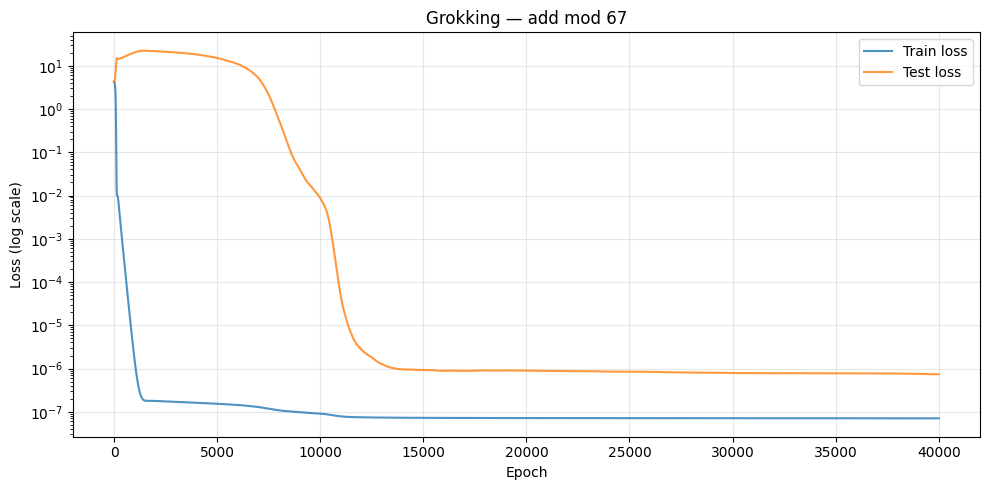

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
epochs = np.arange(len(trainer.train_losses))
ax.semilogy(epochs, trainer.train_losses, label='Train loss', alpha=0.8)
ax.semilogy(epochs, trainer.test_losses, label='Test loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title(f'Grokking — {config.fn_name} mod {config.p}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Verify checkpoint file

In [13]:
# Quick sanity check: load the file and verify its structure
frd = t.load(SAVE_ROOT / 'full_run_data.pth', map_location='cpu', weights_only=False)
print("Keys:", list(frd.keys()))
print(f"state_dicts : {len(frd['state_dicts'])} checkpoints")
print(f"epochs      : {frd['epochs'][:5]} ... {frd['epochs'][-3:]}")
print(f"train_losses: {len(frd['train_losses'])} entries")
print(f"test_losses : {len(frd['test_losses'])} entries")
print(f"config      : {frd['config']}")
print()
print("✓ Ready for Grokking_Analysis.ipynb")

Keys: ['state_dicts', 'epochs', 'train_losses', 'test_losses', 'config']
state_dicts : 401 checkpoints
epochs      : [0, 100, 200, 300, 400] ... [39800, 39900, 40000]
train_losses: 40000 entries
test_losses : 40000 entries
config      : {'lr': 0.001, 'weight_decay': 1.0, 'num_epochs': 40000, 'p': 67, 'fn_name': 'add', 'frac_train': 0.3, 'seed': 0, 'num_layers': 1, 'd_model': 128, 'num_heads': 4, 'n_ctx': 3, 'act_type': 'ReLU', 'use_ln': False, 'save_every': 100, 'stopping_thresh': -1.0, 'log_every': 100}

✓ Ready for Grokking_Analysis.ipynb
